# Analyse de sentiments IMDB – modèle XGBoost
Ce notebook présente un pipeline complet pour analyser des critiques de films IMDB, depuis le chargement des données jusqu'à la sélection du meilleur modèle.

Objectifs :
- comprendre le dataset
- nettoyer et vectoriser le texte
- entraîner un modèle de classification binaire
- évaluer sa performance
- explorer plusieurs hyperparamètres et visualiser leurs effets
- choisir et sauvegarder le meilleur modèle

In [29]:
import re
import string

import joblib
import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBClassifier

# nltk resources pour le preprocessing
# nltk.download('punkt')
# nltk.download('stopwords')

RANDOM_STATE = 42
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Chargement et exploration initiale des données
Nous commençons par ouvrir le dataset IMDB et vérifier sa structure, la distribution des étiquettes et quelques exemples.

In [30]:
df = pd.read_csv('../Model/data/IMDB Dataset.csv')

print('Taille du jeu de données :', df.shape)
print('\nDistribution des classes :')
print(df['sentiment'].value_counts(normalize=True).rename('%').mul(100))

df.head(5)

Taille du jeu de données : (50000, 2)

Distribution des classes :
sentiment
positive    50.0
negative    50.0
Name: %, dtype: float64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 2. Préparation du texte
Nous nettoyons les critiques en supprimant les balises HTML, les caractères d'échappement, puis en tokenisant et en filtrant les stopwords et la ponctuation.

In [31]:
stop_words = set(stopwords.words('english'))
punct_marks = set(string.punctuation)


def clean_text(text: str) -> str:
    text = re.sub(r'<.*?>', '', text)
    text = text.replace('\\', ' ')
    text = text.replace('\n', ' ')
    return text.strip()


def tokenize_and_filter(text: str) -> str:
    sentences = sent_tokenize(text)
    tokens = []
    for sentence in sentences:
        for token in word_tokenize(sentence):
            token = token.lower()
            if token.isalpha() and token not in stop_words and token not in punct_marks:
                tokens.append(token)
    return ' '.join(tokens)


def preprocess_text(series: pd.Series) -> pd.Series:
    return series.map(clean_text).map(tokenize_and_filter)

print('Nettoyage en cours...')
df['review_clean'] = preprocess_text(df['review'])

df[['review', 'review_clean', 'sentiment']].head(5)

Nettoyage en cours...


,review,review_clean,sentiment
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode ho...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically family little boy jake thinks zombie...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...,positive


### Vérification après nettoyage
On vérifie quelques critiques nettoyées pour s'assurer que la pipeline fonctionne comme prévu.

In [32]:
for index, row in df.sample(3, random_state=RANDOM_STATE).iterrows():
    print(f"--- Exemple {index} ({row['sentiment']}) ---")
    print('Original :', row['review'][:300], '...')
    print('Nettoyé  :', row['review_clean'][:300], '...\n')

--- Exemple 33553 (positive) ---
Original : I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok  ...
Nettoyé  : really liked summerslam due look arena curtains look overall interesting reason anyways could one best summerslam ever wwf lex luger main event yokozuna time ok huge fat man vs strong man glad times changed terrible main event like every match luger terrible matches card razor ramon vs ted dibiase s ...

--- Exemple 9427 (positive) ---
Original : Not many television shows appeal to quite as many different kinds of fans like Farscape does...I know youngsters and 30/40+ years old;fans both Male and Female in as many different countries as you can think of that just adore this T.V miniseries. It has elements that can be found in almost

## 3. Vectorisation TF-IDF
Nous transformons les textes nettoyés en vecteurs numériques avec TF-IDF pour alimenter le classifieur.

In [33]:
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['review_clean'])
y = df['sentiment'].map({'positive': 1, 'negative': 0}).astype(int)

print('Dimension du vocabulaire TF-IDF :', len(vectorizer.vocabulary_))
print('Matrice X shape :', X.shape)

Dimension du vocabulaire TF-IDF : 20000
Matrice X shape : (50000, 20000)


## 4. Séparation train/test et entraînement initial
Nous créons un jeu de validation et entraînons un premier modèle XGBoost pour établir une base de référence.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

base_model = XGBClassifier(
    learning_rate=0.05,
    max_depth=7,
    n_estimators=200,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

base_model.fit(X_train, y_train)
y_pred = base_model.predict(X_test)
base_accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy du modèle de base : {base_accuracy:.4f}')
print('\nRapport de classification :')
print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

c:\Users\Sossa Daniel\Documents\ProjectData\C-DAT-300-ABJ-2-2-endtoendml-8-main\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:46:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy du modèle de base : 0.8353

Rapport de classification :
              precision    recall  f1-score   support

    negative       0.86      0.80      0.83      5000
    positive       0.81      0.87      0.84      5000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



## 5. Évaluation détaillée du modèle de base
Visualisons la matrice de confusion pour comprendre les erreurs restantes.

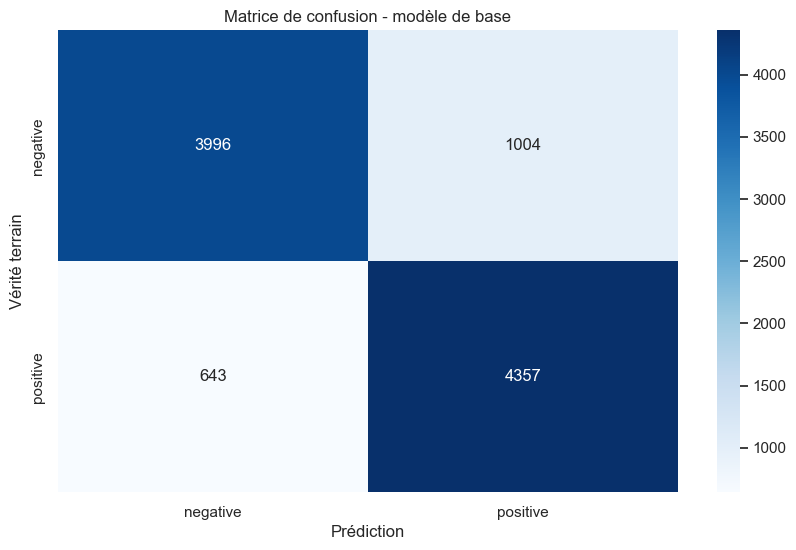

In [35]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])
plt.title('Matrice de confusion - modèle de base')
plt.xlabel('Prédiction')
plt.ylabel('Vérité terrain')
plt.show()

## 6. Recherche d'hyperparamètres
Nous allons tester plusieurs combinaisons de `max_depth`, `learning_rate` et `n_estimators` pour trouver la configuration la plus performante.

In [ ]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}

search_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=search_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=2,
    verbose=1,
    n_jobs=-1,
    return_train_score=False
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print('Meilleurs hyperparamètres :', best_params)
print(f'Accuracy CV moyenne du meilleur modèle : {best_score:.4f}')

Fitting 2 folds for each of 27 candidates, totalling 54 fits


### Visualisation des résultats de Grid Search
Comparer visuellement les scores permet d'identifier rapidement les tendances et le meilleur compromis.

In [ ]:
results = pd.DataFrame(grid_search.cv_results_)
results = results[['param_max_depth', 'param_learning_rate', 'param_n_estimators', 'mean_test_score']]
results = results.sort_values(by='mean_test_score', ascending=False)
results.head(10)

In [ ]:
# Affichage simple des meilleures combinaisons
fig, ax = plt.subplots()
for lr in sorted(results['param_learning_rate'].unique()):
    subset = results[results['param_learning_rate'] == lr]
    ax.plot(subset['param_n_estimators'], subset['mean_test_score'], marker='o', label=f'lr={lr}')

ax.set_title('Effet de n_estimators et learning_rate sur l_accuracy')
ax.set_xlabel('n_estimators')
ax.set_ylabel('Accuracy CV moyenne')
ax.legend()
plt.show()

## 7. Entraînement du meilleur modèle et évaluation finale
Nous ré-entraînons le meilleur modèle trouvé et évaluons sa performance sur l'ensemble de test.

In [ ]:
best_model = XGBClassifier(
    **best_params,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred_best)
print(f'Accuracy finale sur le test : {final_accuracy:.4f}')
print('\nRapport de classification final :')
print(classification_report(y_test, y_pred_best, target_names=['negative', 'positive']))

cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])
plt.title('Matrice de confusion - meilleur modèle')
plt.xlabel('Prédiction')
plt.ylabel('Vérité terrain')
plt.show()

## 8. Sauvegarde du modèle et du vectoriseur
Le modèle final et le transformeur TF-IDF sont exportés pour une utilisation future en production.

In [ ]:
joblib.dump(vectorizer, 'frozen_data/vectoriser.pkl')
joblib.dump(best_model, 'frozen_data/ML_model.pkl')
print('Modèle et vectoriseur sauvegardés dans frozen_data/')